# GW170817A LSST KN Light Curves by Redshift

Visualize representative AT2017gfo-like LSST/SNANA light curves from the GW170817A redshift experiment.

The notebook reads the generated retrieval HDF5, selects one typical retained KN light curve in each redshift bin, and plots multi-band luptitude observations as a function of days since the GW event.

## Setup

Adjust the paths below only if the experiment output location changes. The default inputs match the GW170817A LSST retrieval pipeline.

In [1]:
from __future__ import annotations

from pathlib import Path
import json

import h5py
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "grid.color": "#d9d9d9",
    "grid.alpha": 0.55,
    "grid.linewidth": 0.8,
    "axes.spines.top": True,
    "axes.spines.right": True,
    "axes.edgecolor": "black",
    "axes.linewidth": 0.9,
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "axes.titlesize": 17,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.frameon": False,
})

In [2]:
REPO_ROOT = Path("/fred/oz016/bgao_kn/gw-kn-multimodal")
DATA_ROOT = Path("/fred/oz016/bgao_kn/data")

H5_PATH = DATA_ROOT / "ALBEF_dataset" / "gw170817a_lsst_redshift_test.h5"
MANIFEST_PATH = DATA_ROOT / "GW_real_events" / "GW_data" / "GW170817A" / "lsst_redshift_experiment" / "gw170817a_lsst_manifest.csv"
META_PATH = MANIFEST_PATH.with_suffix(".meta.json")

OUTPUT_DIR = REPO_ROOT / "figures" / "gw170817a_redshift_lightcurves"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

H5_PATH, MANIFEST_PATH, OUTPUT_DIR

(PosixPath('/fred/oz016/bgao_kn/data/ALBEF_dataset/gw170817a_lsst_redshift_test.h5'),
 PosixPath('/fred/oz016/bgao_kn/data/GW_real_events/GW_data/GW170817A/lsst_redshift_experiment/gw170817a_lsst_manifest.csv'),
 PosixPath('/fred/oz016/bgao_kn/gw-kn-multimodal/figures/gw170817a_redshift_lightcurves'))

## Load the Light Curve Dataset

The retrieval HDF5 stores optical values as luptitudes with band order `u,g,r,i,z,Y`. Times are stored relative to the GW event in the model-scaled representation used by the ALBEF pipeline; this notebook infers the scale and converts the axis back to days.

In [3]:
BAND_COLORS = {
    "u": "#3b82f6",
    "g": "#10b981",
    "r": "#ef4444",
    "i": "#f59e0b",
    "z": "#8b5cf6",
    "Y": "#6b7280",
}
DEFAULT_TIME_RANGE_DAYS = (-10.0, 20.0)


def _decode_array(values):
    out = []
    for value in values:
        if isinstance(value, bytes):
            out.append(value.decode("utf-8"))
        else:
            out.append(str(value))
    return np.asarray(out)


def infer_time_scale_to_days(times, masks):
    observed = np.asarray(masks).sum(axis=2) > 0
    if not np.any(observed):
        return 1.0
    max_abs_time = float(np.nanmax(np.abs(np.asarray(times)[observed])))
    # The model stores days / 100, e.g. -0.1..0.2 for -10..20 days.
    return 100.0 if max_abs_time < 5.0 else 1.0


def load_gw170817a_lightcurves(h5_path: Path):
    with h5py.File(h5_path, "r") as f:
        opt = f["events/optical_data"]
        gw = f["events/gw_data"]
        attrs = dict(f.attrs)
        band_order = str(attrs.get("lupt_band_order", "u,g,r,i,z,Y")).split(",")
        data = {
            "times": opt["times"][:].astype(np.float32),
            "values": opt["values"][:].astype(np.float32),
            "errors": opt["errors"][:].astype(np.float32),
            "masks": opt["masks"][:].astype(np.float32),
            "coordinates": opt["coordinates"][:].astype(np.float32),
            "zero_time_mjd_base": opt["zero_time_mjd_base"][:].astype(np.float64),
            "parent_gw_idx": opt["parent_gw_idx"][:].astype(np.int64),
            "event_time_mjd": gw["event_time_mjd"][:].astype(np.float64),
            "redshift": gw["redshift"][:].astype(np.float64),
            "redshift_bin": gw["redshift_bin"][:].astype(np.int64),
            "credible_level": gw["credible_level"][:].astype(np.float32),
            "ids": _decode_array(gw["ids"][:]),
            "attrs": attrs,
            "band_order": band_order,
        }
    data["time_scale_to_days"] = infer_time_scale_to_days(data["times"], data["masks"])
    data["time_days"] = data["times"] * data["time_scale_to_days"]
    return data


data = load_gw170817a_lightcurves(H5_PATH)
print(f"Loaded {len(data['redshift'])} retained KN light curves")
print(f"Bands: {data['band_order']}")
print(f"Time scale to days: x{data['time_scale_to_days']:.0f}")
print(f"Photometry representation: {data['attrs'].get('photometry_representation', 'unknown')}")
print(f"Time zero: GW event MJD; max |zero_time_mjd_base - event_time_mjd| = {np.max(np.abs(data['zero_time_mjd_base'] - data['event_time_mjd'])):.3e} days")

Loaded 1836 retained KN light curves
Bands: ['u', 'g', 'r', 'i', 'z', 'Y']
Time scale to days: x100
Photometry representation: luptitude
Time zero: GW event MJD; max |zero_time_mjd_base - event_time_mjd| = 1.288e+01 days


## Retention by Redshift

The generated manifest contains 200 proposed coordinates per redshift bin. The HDF5 contains only retained light curves after SNANA simulation and the HDF5 builder cuts.

In [4]:
manifest = pd.read_csv(MANIFEST_PATH)
meta = json.loads(META_PATH.read_text()) if META_PATH.exists() else {}

retained = (
    pd.DataFrame({"redshift": data["redshift"], "redshift_bin": data["redshift_bin"]})
    .groupby(["redshift_bin", "redshift"], as_index=False)
    .size()
    .rename(columns={"size": "n_retained"})
)
generated = (
    manifest.groupby(["redshift_bin", "redshift"], as_index=False)
    .size()
    .rename(columns={"size": "n_generated"})
)
summary = generated.merge(retained, on=["redshift_bin", "redshift"], how="left")
summary["n_retained"] = summary["n_retained"].fillna(0).astype(int)
summary["retained_fraction"] = summary["n_retained"] / summary["n_generated"]
summary

,redshift_bin,redshift,n_generated,n_retained,retained_fraction
0,0,0.01,800,274,0.342500
1,1,0.02,800,218,0.272500
2,2,0.03,1200,283,0.235833
3,3,0.05,1300,249,0.191538
4,4,0.08,2000,264,0.132000
5,5,0.12,3000,253,0.084333
6,6,0.16,6000,295,0.049167


## Select a Typical Light Curve per Redshift

For each retained redshift bin, the representative sample is chosen closest to the bin median in two simple observability summaries measured inside the plotted time window:

- total number of valid observation slots across all filters;
- brightest observed luptitude across all filters.

This avoids cherry-picking only the brightest or faintest object in each bin while still selecting an actual simulated light curve.

In [5]:
def lightcurve_features(values, masks, time_days, time_range_days=DEFAULT_TIME_RANGE_DAYS):
    time_keep = np.ones_like(time_days, dtype=bool)
    if time_range_days is not None:
        lo, hi = time_range_days
        time_keep = (time_days >= float(lo)) & (time_days <= float(hi))
    valid = (masks > 0) & np.isfinite(values) & time_keep[:, :, None]
    n_obs = valid.sum(axis=(1, 2)).astype(float)
    masked_values = np.where(valid, values, np.nan)
    brightest_luptitude = np.nanmin(masked_values.reshape(masked_values.shape[0], -1), axis=1)
    finite_peak = np.isfinite(brightest_luptitude)
    if np.any(finite_peak):
        fill_value = float(np.nanmedian(brightest_luptitude[finite_peak]))
    else:
        fill_value = np.nan
    brightest_luptitude = np.where(finite_peak, brightest_luptitude, fill_value)
    return n_obs, brightest_luptitude


def select_typical_indices(data, time_range_days=DEFAULT_TIME_RANGE_DAYS):
    n_obs, brightest = lightcurve_features(data["values"], data["masks"], data["time_days"], time_range_days)
    records = []
    selected = []
    for bin_id in sorted(np.unique(data["redshift_bin"])):
        idx = np.where(data["redshift_bin"] == bin_id)[0]
        if idx.size == 0:
            continue
        has_window_obs = n_obs[idx] > 0
        candidate_idx = idx[has_window_obs] if np.any(has_window_obs) else idx
        med_n = float(np.median(n_obs[candidate_idx]))
        med_brightest = float(np.nanmedian(brightest[candidate_idx]))
        n_scale = float(np.std(n_obs[candidate_idx])) or 1.0
        b_scale = float(np.nanstd(brightest[candidate_idx])) or 1.0
        score = ((n_obs[candidate_idx] - med_n) / n_scale) ** 2 + ((brightest[candidate_idx] - med_brightest) / b_scale) ** 2
        chosen = int(candidate_idx[np.nanargmin(score)])
        selected.append(chosen)
        records.append({
            "sample_index": chosen,
            "redshift_bin": int(data["redshift_bin"][chosen]),
            "redshift": float(data["redshift"][chosen]),
            "event_id": data["ids"][chosen],
            "ra_deg": float(data["coordinates"][chosen, 0]),
            "dec_deg": float(data["coordinates"][chosen, 1]),
            "credible_level": float(data["credible_level"][chosen]),
            "n_observations_in_window": int(n_obs[chosen]),
            "brightest_luptitude_in_window": float(brightest[chosen]),
        })
    return selected, pd.DataFrame.from_records(records)


typical_indices, typical_table = select_typical_indices(data, DEFAULT_TIME_RANGE_DAYS)
typical_table

,sample_index,redshift_bin,redshift,event_id,ra_deg,dec_deg,credible_level,n_observations_in_window,brightest_luptitude_in_window
0,240,0,0.01,gw170817a_727,228.302750,-69.979485,0.865285,12,18.275444
1,303,1,0.02,gw170817a_919,189.316406,-9.594068,0.323823,13,19.502834
2,503,2,0.03,gw170817a_1665,4.402174,-73.126884,0.487965,13,20.037704
3,822,3,0.05,gw170817a_3059,193.886719,-15.094787,0.671762,13,20.828629
4,1272,4,0.08,gw170817a_5937,192.480469,-13.861950,0.074626,14,21.788176
5,1468,5,0.12,gw170817a_8180,191.777344,-11.415158,0.347356,15,22.441803
6,1567,6,0.16,gw170817a_9578,185.449219,-1.492246,0.336738,14,22.969736


## Plot Representative Multi-band Light Curves

The y-axis is luptitude, so lower values are brighter and the axis is inverted. The time axis is fixed to `[-10, 20]` days relative to the GW event. Empty redshift bins, such as `z=0.22` in the current HDF5, are omitted automatically.

PosixPath('/fred/oz016/bgao_kn/gw-kn-multimodal/figures/gw170817a_redshift_lightcurves/gw170817a_typical_kn_lightcurves_by_redshift.png')

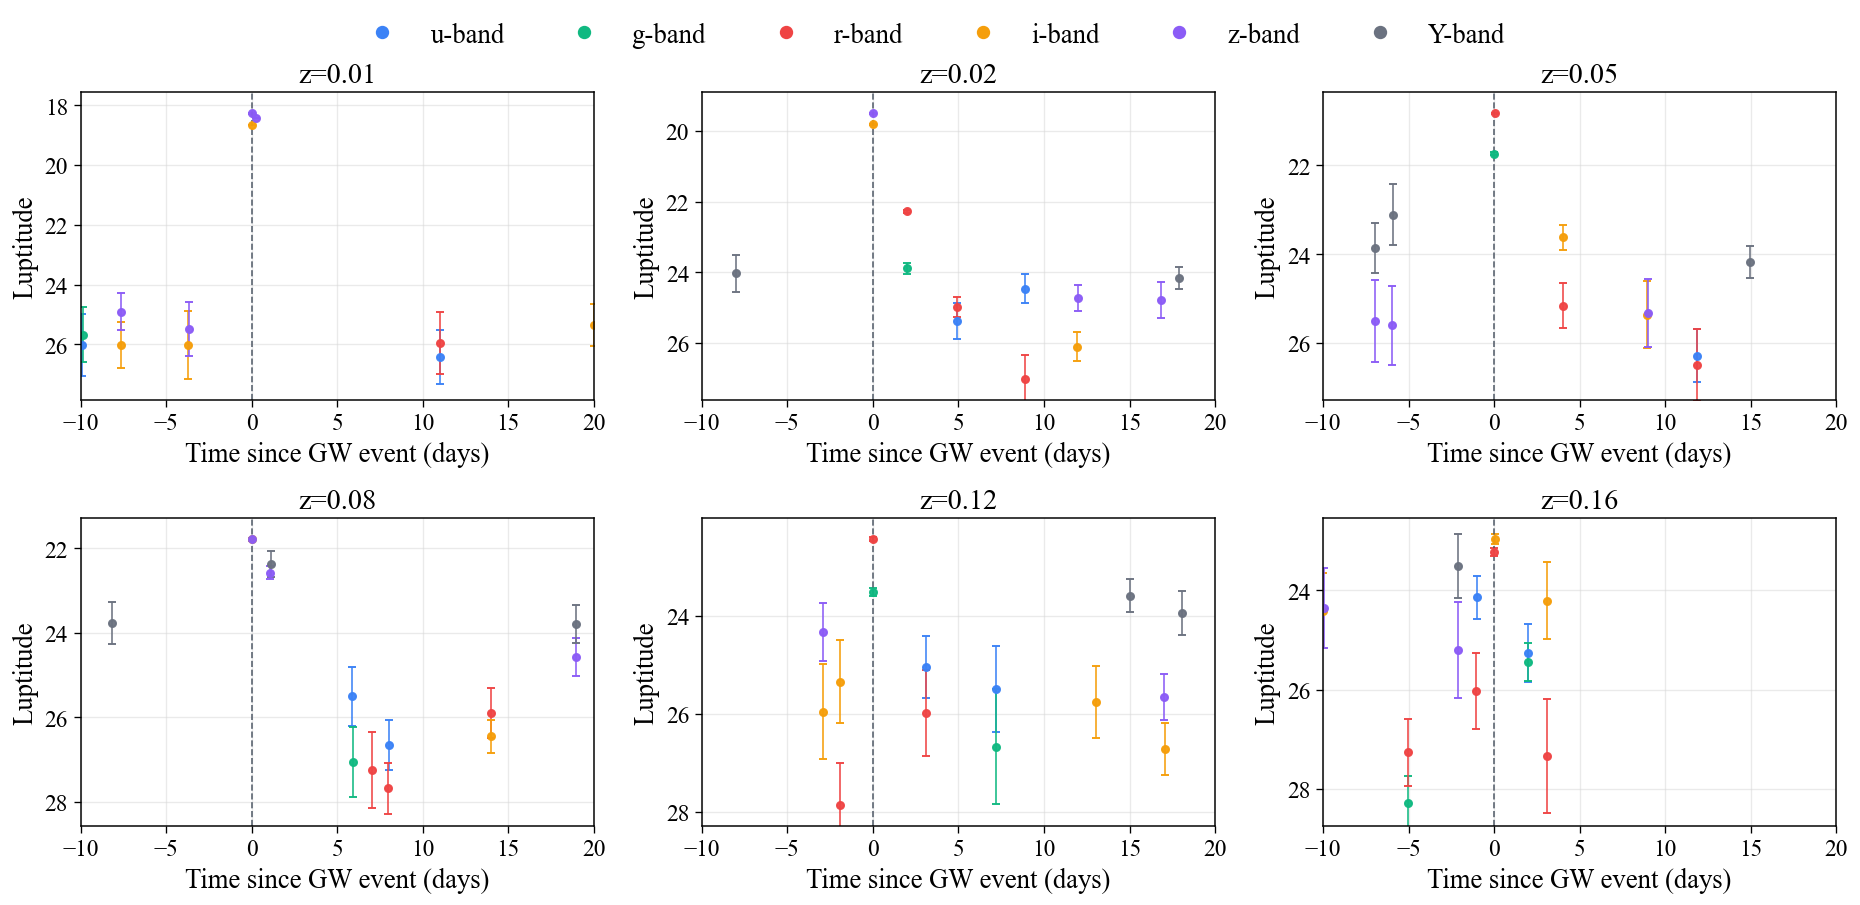

In [6]:
def style_closed_axes(ax):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.9)
        spine.set_color("black")
    ax.tick_params(axis="both", which="both", direction="out", top=False, right=False, length=4, width=0.8)
    ax.grid(True, color="#d9d9d9", alpha=0.55, linewidth=0.8)


def band_legend_handles(bands):
    return [
        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="None",
            color=BAND_COLORS.get(band, "C0"),
            markerfacecolor=BAND_COLORS.get(band, "C0"),
            markeredgecolor=BAND_COLORS.get(band, "C0"),
            markersize=7,
            label=f"{band}-band",
        )
        for band in bands
    ]


def set_luptitude_ylim(ax, values, errors):
    values = np.asarray(values, dtype=float)
    errors = np.asarray(errors, dtype=float)
    finite = np.isfinite(values)
    if not np.any(finite):
        ax.set_ylim(30.5, 22.0)
        return
    lo = float(np.nanmin(values[finite]))
    hi = float(np.nanmax(values[finite]))
    err_hi = values[finite] + np.nan_to_num(errors[finite], nan=0.0)
    hi = max(hi, float(np.nanpercentile(err_hi, 90)))
    pad = max(0.35, 0.08 * max(hi - lo, 1.0))
    ax.set_ylim(hi + pad, lo - pad)


def plot_lightcurve_panel(ax, sample_index, data, *, time_range_days=DEFAULT_TIME_RANGE_DAYS, show_errors=True):
    bands = data["band_order"]
    t_days = data["time_days"][sample_index]
    values = data["values"][sample_index]
    errors = data["errors"][sample_index]
    masks = data["masks"][sample_index]
    plotted_values = []
    plotted_errors = []

    for band_idx, band in enumerate(bands):
        valid = masks[:, band_idx] > 0
        if time_range_days is not None:
            lo, hi = time_range_days
            valid = valid & (t_days >= lo) & (t_days <= hi)
        valid = valid & np.isfinite(values[:, band_idx]) & np.isfinite(errors[:, band_idx])
        if not np.any(valid):
            continue
        color = BAND_COLORS.get(band, None)
        plotted_values.append(values[valid, band_idx])
        plotted_errors.append(errors[valid, band_idx])
        if show_errors:
            ax.errorbar(
                t_days[valid],
                values[valid, band_idx],
                yerr=errors[valid, band_idx],
                fmt="o",
                ms=4.2,
                mew=1.2,
                lw=0.0,
                elinewidth=1.0,
                capsize=2.2,
                alpha=0.95,
                color=color,
                markerfacecolor=color,
                markeredgecolor=color,
                label=band,
            )
        else:
            ax.scatter(t_days[valid], values[valid, band_idx], s=22, alpha=0.95, color=color, label=band)

    z = data["redshift"][sample_index]
    ax.set_title(f"z={z:.2f}")
    ax.set_xlabel("Time since GW event (days)")
    ax.set_ylabel("Luptitude")
    ax.axvline(0.0, color="#4b5563", lw=1.0, ls="--", alpha=0.9)
    if time_range_days is not None:
        ax.set_xlim(*time_range_days)
    if plotted_values:
        set_luptitude_ylim(ax, np.concatenate(plotted_values), np.concatenate(plotted_errors))
    else:
        ax.set_ylim(30.5, 22.0)
    style_closed_axes(ax)


def plot_typical_redshift_grid(data, typical_indices, *, time_range_days=DEFAULT_TIME_RANGE_DAYS, show_errors=True):
    n = len(typical_indices)
    ncols = 3
    nrows = 2
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 4.3 * nrows), sharex=False, sharey=False)
    axes = np.atleast_1d(axes).ravel()

    for ax, sample_index in zip(axes, typical_indices):
        plot_lightcurve_panel(ax, sample_index, data, time_range_days=time_range_days, show_errors=show_errors)
    for ax in axes[len(typical_indices):]:
        ax.axis("off")

    handles = band_legend_handles(data["band_order"])
    fig.legend(handles=handles, loc="upper center", ncol=len(handles), bbox_to_anchor=(0.5, 0.885), fontsize=16)
    fig.tight_layout(rect=(0, 0, 1, 0.84), h_pad=1.25, w_pad=1.65)
    return fig


# Exclude z=0.03 (redshift_bin=2) — keep a clean 2x3 grid
filtered_indices = [idx for idx in typical_indices if data["redshift"][idx] != 0.03]
fig = plot_typical_redshift_grid(data, filtered_indices, time_range_days=DEFAULT_TIME_RANGE_DAYS, show_errors=True)
fig_path = OUTPUT_DIR / "gw170817a_typical_kn_lightcurves_by_redshift.png"
fig.savefig(fig_path, bbox_inches="tight")
fig.savefig(OUTPUT_DIR / "gw170817a_typical_kn_lightcurves_by_redshift.pdf", bbox_inches="tight")
fig_path

## Optional: Compare All Retained Curves in a Redshift Bin

Use this cell to inspect the spread around a chosen redshift. The grey traces show all retained light curves in one band, and the colored line highlights the representative sample selected above.

PosixPath('/fred/oz016/bgao_kn/gw-kn-multimodal/figures/gw170817a_redshift_lightcurves/gw170817a_z0p05_rband_population.png')

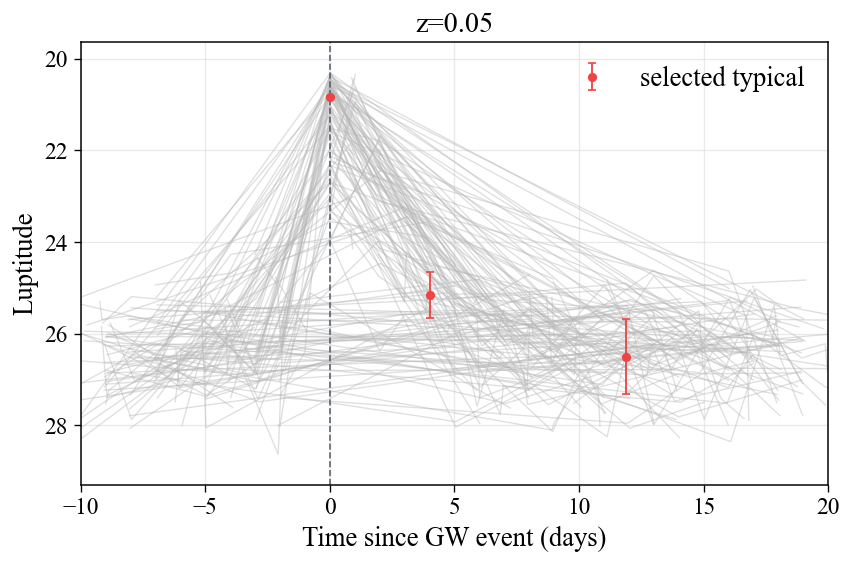

In [7]:
def plot_redshift_bin_population(data, redshift=0.05, band="r", time_range_days=DEFAULT_TIME_RANGE_DAYS):
    bands = data["band_order"]
    band_idx = bands.index(band)
    z_values = np.asarray(data["redshift"])
    idx = np.where(np.isclose(z_values, float(redshift)))[0]
    if idx.size == 0:
        raise ValueError(f"No retained light curves found for redshift={redshift}")

    fig, ax = plt.subplots(figsize=(7.2, 4.8))
    all_values = []
    all_errors = []
    for sample_index in idx:
        t = data["time_days"][sample_index]
        y = data["values"][sample_index, :, band_idx]
        yerr = data["errors"][sample_index, :, band_idx]
        valid = data["masks"][sample_index, :, band_idx] > 0
        if time_range_days is not None:
            lo, hi = time_range_days
            valid = valid & (t >= lo) & (t <= hi)
        valid = valid & np.isfinite(y) & np.isfinite(yerr)
        if np.any(valid):
            order = np.argsort(t[valid])
            all_values.append(y[valid])
            all_errors.append(yerr[valid])
            ax.plot(t[valid][order], y[valid][order], color="0.72", lw=0.8, alpha=0.45)

    typical_for_z = typical_table.loc[np.isclose(typical_table["redshift"], float(redshift)), "sample_index"]
    if not typical_for_z.empty:
        sample_index = int(typical_for_z.iloc[0])
        t = data["time_days"][sample_index]
        y = data["values"][sample_index, :, band_idx]
        yerr = data["errors"][sample_index, :, band_idx]
        valid = data["masks"][sample_index, :, band_idx] > 0
        if time_range_days is not None:
            lo, hi = time_range_days
            valid = valid & (t >= lo) & (t <= hi)
        valid = valid & np.isfinite(y) & np.isfinite(yerr)
        if np.any(valid):
            order = np.argsort(t[valid])
            all_values.append(y[valid])
            all_errors.append(yerr[valid])
            ax.errorbar(
                t[valid][order],
                y[valid][order],
                yerr=yerr[valid][order],
                fmt="o",
                ms=4.5,
                elinewidth=1.1,
                capsize=2.2,
                color=BAND_COLORS.get(band, "C3"),
                markerfacecolor=BAND_COLORS.get(band, "C3"),
                markeredgecolor=BAND_COLORS.get(band, "C3"),
                label="selected typical",
            )

    ax.set_title(f"z={redshift:.2f}")
    ax.set_xlabel("Time since GW event (days)")
    ax.set_ylabel("Luptitude")
    ax.axvline(0.0, color="#4b5563", lw=1.0, ls="--", alpha=0.9)
    if time_range_days is not None:
        ax.set_xlim(*time_range_days)
    if all_values:
        set_luptitude_ylim(ax, np.concatenate(all_values), np.concatenate(all_errors))
    else:
        ax.set_ylim(30.5, 22.0)
    style_closed_axes(ax)
    ax.legend(fontsize=16)
    fig.tight_layout()
    return fig


fig = plot_redshift_bin_population(data, redshift=0.05, band="r")
pop_path = OUTPUT_DIR / "gw170817a_z0p05_rband_population.png"
fig.savefig(pop_path, bbox_inches="tight")
fig.savefig(OUTPUT_DIR / "gw170817a_z0p05_rband_population.pdf", bbox_inches="tight")
pop_path

## Notes for Interpretation

- The plot shows only retained SNANA/HDF5 light curves. The highest planned redshift bin, `z=0.22`, currently has zero retained samples and therefore does not appear.
- Luptitude is magnitude-like but remains well behaved at low or negative flux. Lower luptitude values are brighter.
- The selected sample is representative under a simple observation-count and peak-luptitude criterion inside the plotted time window. For publication figures, you may prefer to select the median peak luminosity, the brightest detected event, or several examples per redshift.